<a href="https://colab.research.google.com/github/georgemulu/analystlab-internship/blob/main/Netflix_Movies_and_Tv_Shows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Understanding

In [ ]:
df = pd.read_csv('netflix_titles.csv')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

**Datatypes**

In [ ]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


Numerical columns

In [ ]:
df.select_dtypes(include=['int64','float64']).columns

Index(['release_year'], dtype='object')

Categorical columns

In [ ]:
df.select_dtypes(include='object').columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Unique Identifier

In [ ]:
df['show_id'].is_unique

True

The dataset contains information on film titles on netflix including cast, country of origin, director, date it was added on the platform, rating, duration, genres its classified in and a small description of the movies

# Data cleaning

## Missing values

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['director'] = df['director'].fillna('Unknown')

In [ ]:
df['cast'] = df['cast'].fillna('Not Available')

In [ ]:
df['country'] = df['country'].fillna('Unknown')

I decided to impute the missing values with placeholders for the above columns since all other information in the rows is useful and also ensures categorical consistency

In [ ]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
df[df['rating'].isin(['74 min', '84 min','66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


Let's move the values of rating that end with min to the respective duration column

In [ ]:
mask = df['rating'].str.contains('min', na=False)
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = np.nan

In [ ]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', nan, 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

Now our rating column is clean

In [ ]:
df[df['rating'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,NaN,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,NaN,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,NaN,66 min,Movies,The comic puts his trademark hilarious/thought...
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Unknown,"Oprah Winfrey, Ava DuVernay",Unknown,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Unknown,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,Unknown,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


I will fill the missing values in the rating column with the placeholder value 'unknown' this is to prevent wrong assumptions

In [ ]:
df['rating'] = df['rating'].fillna('Unknown')

In [ ]:
df['duration'].isna().sum()

np.int64(0)

Since I filled the null values in the duration column with the values from the rating column , duration does not have null values

In [ ]:
df[df['date_added'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,Unknown,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,Unknown,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,Unknown,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,Unknown,Igor Dmitriev,Unknown,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,Unknown,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,Unknown,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,Unknown,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,Unknown,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


Since the rows that have missing date_added values consequently don't have director values I will use placeholder value 'Unknown' to enssure consistency

In [ ]:
df['date_added'] = df['date_added'].fillna('Unknown')

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


Now we have no missing values

## Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

We have no duplicate records

## Standardization

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


We will change the date_added column to datetime format

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [ ]:
df['show_id'] = df['show_id'].str.upper()

In [ ]:
df['show_id'].head()

,show_id
0,S1
1,S2
2,S3
3,S4
4,S5


In [ ]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

All other columns have valid values

# Summary Table

In [ ]:
changes = [
    {"Issue Found": "Missing Values","Action Taken": "Filled"},
    {"Issue Found": "Standardization", "Action Taken" : "Applied" }

]
summary_df = pd.DataFrame(changes)
summary_df

,Issue Found,Action Taken
0,Missing Values,Filled
1,Standardization,Applied


# Exploratory Data Analysis

## Summary statistics

In [ ]:
df.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290816,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


## Data Patterns

### Rating by movie count

In [ ]:
top_ratings = df['rating'].value_counts().head(10)
top_ratings

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


### Content Type Distribution

In [ ]:
type_counts = df['type'].value_counts()
type_counts

,count
type,
Movie,6131
TV Show,2676


### Movie count by release year

In [ ]:
release_counts = df['release_year'].value_counts().head(10)
release_counts

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


### Top content producing countries

To do country level analysis we will split the column by comma into a list by creating a new country column that has the string split into a list using the assign function.


We then transform the list entries into separate rows using the explode function in this way a movie will appear more than once if it had multiple countries listed and for each country it was listed in will have a separate row for the country.

In [ ]:
df_countries = df.assign(county=df['country'].str.split(',')).explode('country')
df_countries['country'] = df_countries['country'].str.strip()

country_counts = df_countries['country'].value_counts().head(10)
country_counts

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


United states leads as the country producing the most movies on the platform followed by India.

### Most common categories



To do genre level analysis we will split the column by comma into a list using the assign function and then we transform the list entries into separate rows using the explode function in this way a movie will appear more than once if it had multiple genres listed and for each genre it was listed in will have a separate row for the genre.

In [ ]:
df_genres = df.assign(listed_in=df['listed_in'].str.split(',')).explode('listed_in')
df_genres['listed_in'] = df_genres['listed_in'].str.strip()

genre_counts = df_genres['listed_in'].value_counts().head(10)
genre_counts

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


### Director counts

In [ ]:
director_counts = df['director'].value_counts().head(10)
director_counts

,count
director,
Unknown,2634
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


### Content added by year

In [ ]:
df['year_added'] = df['date_added'].dt.year
year_counts = df['year_added'].value_counts().head(10)
year_counts

,count
year_added,
2019.0,1999
2020.0,1878
2018.0,1625
2021.0,1498
2017.0,1164
2016.0,418
2015.0,73
2014.0,23
2011.0,13


# Data Visualization

Text(0, 0.5, 'Movie Count')

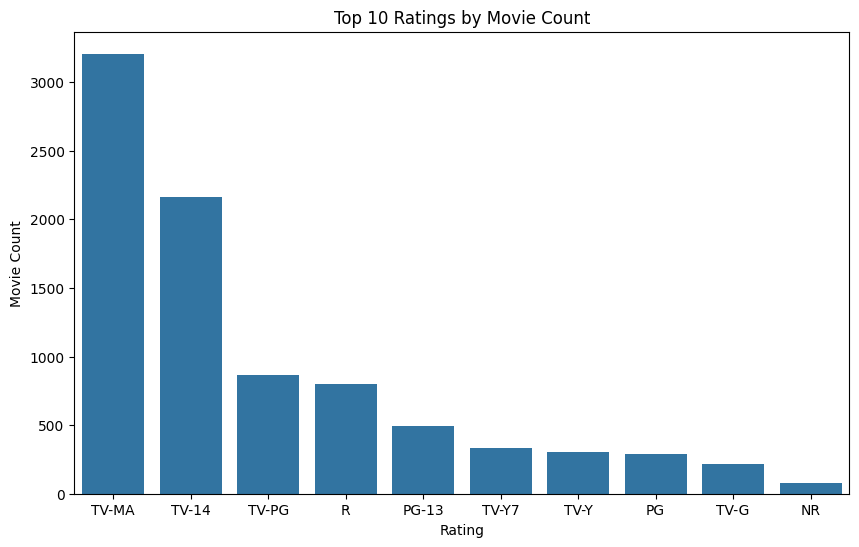

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=top_ratings.index, y=top_ratings.values, ax=ax)
ax.set_title('Top 10 Ratings by Movie Count')
ax.set_xlabel('Rating')
ax.set_ylabel('Movie Count')

Most titles are rated for mature audiences, with **'TV-MA'** and **'TV-14'** being the most common ratings. This is followed by 'TV-PG' and 'R' ratings.

Text(0.5, 1.0, 'Content Type Distribution')

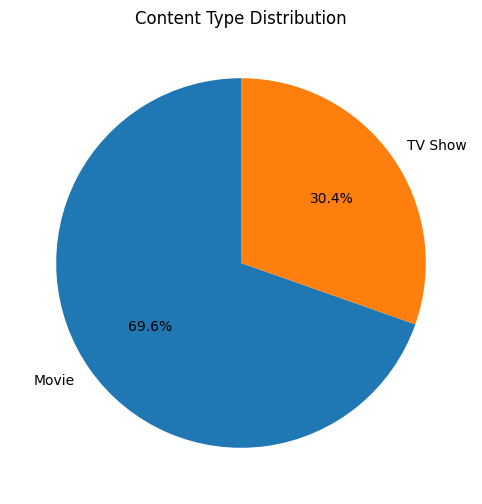

In [ ]:
fig, ax = plt.subplots(figsize = (10,6))
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Content Type Distribution')

Netflix content is predominantly **Movies**, making up **69.6%** of the titles, while **TV Shows** account for **30.4%**.

Text(0.5, 0, 'Release Year')

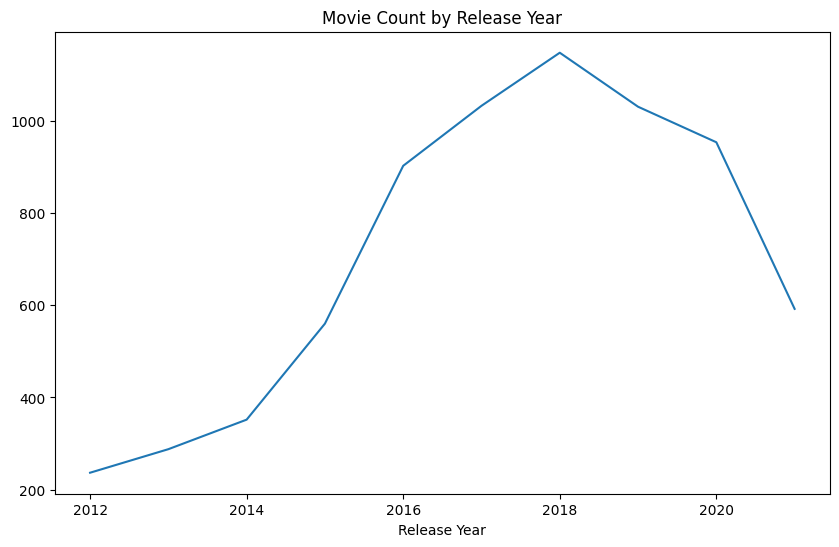

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x=release_counts.index, y=release_counts.values, ax=ax)
ax.set_title('Movie Count by Release Year')
ax.set_xlabel('Release Year')

There was an upward trend in the number of movies released on the platform from 2012, peaking in **2018** . A downward trend is observed from 2019 onwards.

/tmp/ipykernel_682/2463408185.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60)


Text(0.5, 1.0, 'Top Content Producing Countries')

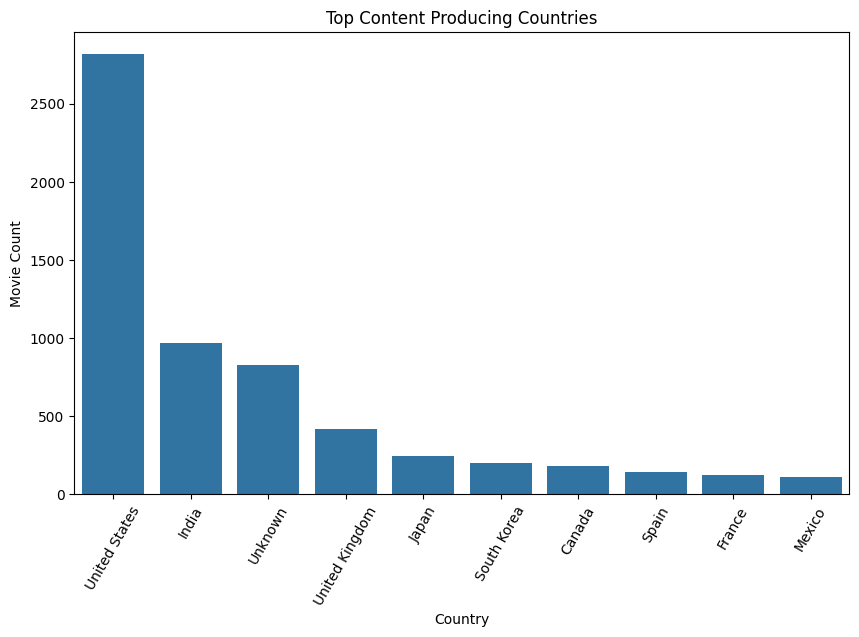

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=country_counts.index, y=country_counts.values, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=60)
ax.set_xlabel('Country')
ax.set_ylabel('Movie Count')
ax.set_title('Top Content Producing Countries')

The **United States** leads significantly in content production followed by **India**. A notable portion also remains 'Unknown' due to prior imputation.

/tmp/ipykernel_682/2473786547.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60)


[Text(0, 0, 'International Movies'),
 Text(1, 0, 'Dramas'),
 Text(2, 0, 'Comedies'),
 Text(3, 0, 'International TV Shows'),
 Text(4, 0, 'Documentaries'),
 Text(5, 0, 'Action & Adventure'),
 Text(6, 0, 'TV Dramas'),
 Text(7, 0, 'Independent Movies'),
 Text(8, 0, 'Children & Family Movies'),
 Text(9, 0, 'Romantic Movies')]

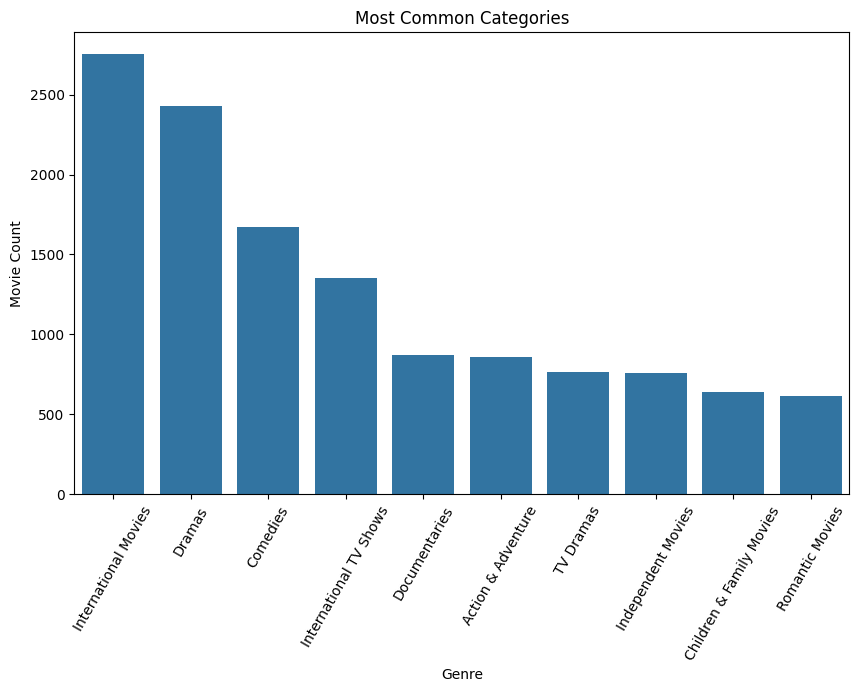

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax)
ax.set_xlabel('Genre')
ax.set_ylabel('Movie Count')
ax.set_title('Most Common Categories')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60)

**'International Movies'** is the most common category, followed by 'Dramas' and 'Comedies'. This indicates a strong global content focus.


/tmp/ipykernel_682/351654238.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60)


Text(0, 0.5, 'Movie Count')

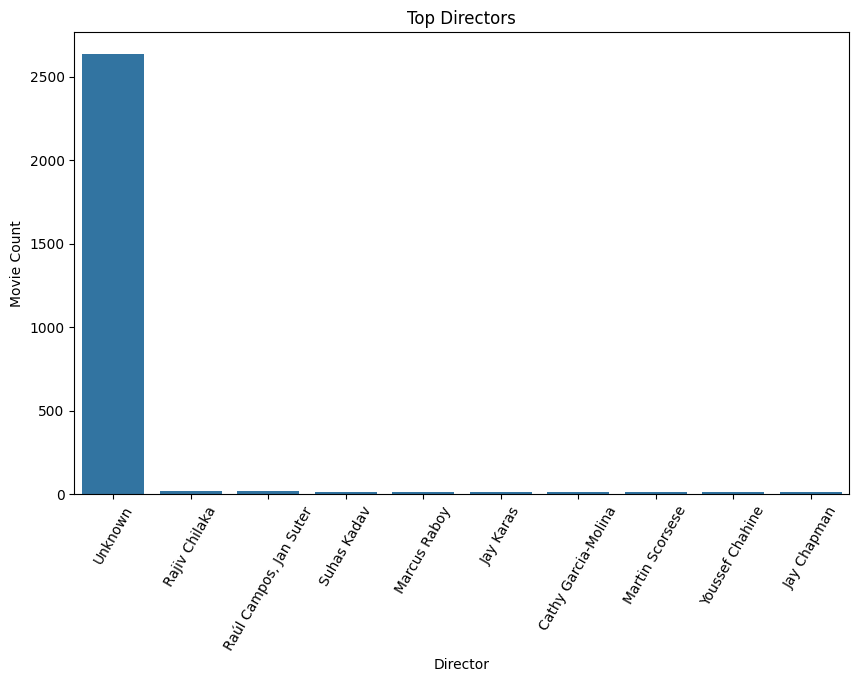

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=director_counts.index, y=director_counts.values, ax=ax)
ax.set_xlabel('Director')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60)
ax.set_title('Top Directors')
ax.set_ylabel('Movie Count')

The 'Unknown' director category is by far the largest, which is a direct consequence of the imputation strategy for missing values. Among known directors, Rajiv Chilaka has the highest count.

Text(0.5, 1.0, 'Content Added by Year')

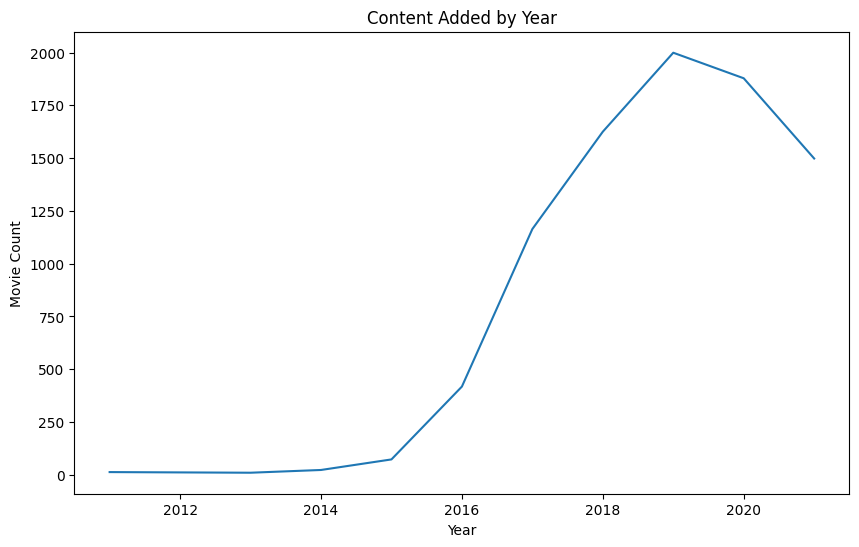

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x=year_counts.index, y=year_counts.values, ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Movie Count')
ax.set_title('Content Added by Year')

The volume of content added to Netflix showed a strong upward trend from 2011, reaching its peak in **2019**. A decrease in additions is noted from 2020.

# Insights

- **Mature Content Dominance:** Netflix's content library is predominantly geared towards mature audiences, with 'TV-MA' and 'TV-14' being the most prevalent ratings. As illustrated in the "Top 10 Ratings by Movie Count" bar chart, these two categories account for the largest proportion of titles on the platform.
- **Peak Content Production and Addition (2018-2019):** The period between 2018 and 2019 represented a peak for Netflix in terms of both content release and acquisition. The "Movie Count by Release Year" line plot demonstrates a peak in content released around 2018, while the "Content Added by Year" line plot shows a high volume of titles added to the platform in 2019. A subsequent decline in both metrics from 2020 onwards could indicate a shift in content strategy or production cycles.
- **Global Content Focus:** Netflix demonstrates a strong global content focus. The "Most Common Categories" bar chart reveals that 'International Movies' is the leading genre, reflecting a diverse offering. Furthermore, the "Top Content Producing Countries" bar chart highlights the United States and India as significant contributors, underscoring Netflix's global reach and strategy for content diversification.
- **Data Quality Implications:** A considerable number of titles have 'Unknown' entries for both directors and countries, as evident in the "Top Directors" and "Top Content Producing Countries" bar charts. This suggests potential data quality issues in the original dataset, which could limit the depth of analysis for these specific attributes, making it challenging to identify actual top directors or less represented countries.

In [ ]:
from google.colab import files
df.to_csv('netflix_cleaned.csv', index=False)
files.download('netflix_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>